In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from copy import deepcopy

plt.rcParams['figure.figsize'] = (8,4)
sns.set_style("whitegrid")

In [35]:
def print_coef_stats(name, coef, intercept, X_cols):
    coef = coef.ravel()
    print(f"--- {name} ---")
    
    if hasattr(intercept, "__len__") and len(intercept) == 1:
        val = intercept[0]
    else:
        val = intercept
        
    print("Intercept:", float(val))
    print("Norm (L2) of coeffs:", np.linalg.norm(coef))
    print("Sum abs (L1 norm) of coeffs:", np.sum(np.abs(coef)))
    print("Number of zero coefficients:", int(np.sum(np.isclose(coef, 0.0, atol=1e-6))))
    df = pd.DataFrame({'feature': X_cols, 'coef': coef})
    display(df.sort_values('coef', key=lambda s: np.abs(s), ascending=False).head(10))
    print()
    
def plot_coefficients(models_coefs, feature_names, top_n=30):
    n = len(models_coefs)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n==1:
        axes = [axes]
    for ax, (label, coef) in zip(axes, models_coefs):
        coef = coef.ravel()
        ax.bar(range(len(coef)), coef)
        ax.set_ylabel(label)
        ax.set_xticks(range(len(coef)))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()

In [36]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape:", X.shape)
X.head()

Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train shape:", X_train_s.shape, "Test shape:", X_test_s.shape)

Train shape: (455, 30) Test shape: (114, 30)


In [38]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

try:
    base = LogisticRegression(penalty=None, solver='saga', max_iter=10000, random_state=42)
    base.fit(X_train_s, y_train)
    print("Trained with penalty=None (no regularization).")
except Exception as e:
    print("Could not use penalty=None. Error:", e)
    print("Falling back to very large C (approx no regularization).")
    base = LogisticRegression(C=1e6, penalty='l2', solver='saga', max_iter=10000, random_state=42)
    base.fit(X_train_s, y_train)

y_pred_train = base.predict(X_train_s)
y_pred_test  = base.predict(X_test_s)
print("Baseline Train Acc:", accuracy_score(y_train, y_pred_train))
print("Baseline Test  Acc:", accuracy_score(y_test, y_pred_test))

print_coef_stats("Baseline (no/very weak reg)", base.coef_, base.intercept_, X.columns)

scikit-learn version: 1.7.0
Trained with penalty=None (no regularization).
Baseline Train Acc: 0.989010989010989
Baseline Test  Acc: 0.9649122807017544
--- Baseline (no/very weak reg) ---
Intercept: -1.0630545329963803
Norm (L2) of coeffs: 15.534547105638318
Sum abs (L1 norm) of coeffs: 64.7066605772042
Number of zero coefficients: 0


,feature,coef
5,mean compactness,7.809456
26,worst concavity,-5.083194
13,area error,-4.783090
10,radius error,-4.618926
16,concavity error,4.550228
23,worst area,-4.435342
17,concave points error,-3.582355
21,worst texture,-3.351384
6,mean concavity,-2.721095
9,mean fractal dimension,-2.719186


### L2 Regularization

In [ ]:
l2 = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=5000, random_state=42)
l2.fit(X_train_s, y_train)
print("L2 Train Acc:", accuracy_score(y_train, l2.predict(X_train_s)))
print("L2 Test  Acc:", accuracy_score(y_test, l2.predict(X_test_s)))
print_coef_stats("L2 (C=1.0)", l2.coef_, l2.intercept_, X.columns)

L2 Train Acc: 0.989010989010989
L2 Test  Acc: 0.9824561403508771
--- L2 (C=1.0) ---
Intercept: 0.3059426925145964
Norm (L2) of coeffs: 3.574038921473671
Sum abs (L1 norm) of coeffs: 17.169681641771426
Number of zero coefficients: 0


,feature,coef
21,worst texture,-1.239400
10,radius error,-1.077239
27,worst concave points,-0.950395
23,worst area,-0.945525
20,worst radius,-0.942499
28,worst symmetry,-0.938354
13,area error,-0.922785
26,worst concavity,-0.816078
22,worst perimeter,-0.764032
24,worst smoothness,-0.756714


### L2 penalizes the sum of squared coefficients and encourages small (but non-zero) weights. Expect coefficient magnitudes to shrink compared to baseline; weights rarely become exactly zero. This reduces variance at the cost of some bias.

## L1 Regularization

In [40]:
l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=5000, random_state=42)
l1.fit(X_train_s, y_train)
print("L1 Train Acc:", accuracy_score(y_train, l1.predict(X_train_s)))
print("L1 Test  Acc:", accuracy_score(y_test, l1.predict(X_test_s)))
print_coef_stats("L1 (C=1.0)", l1.coef_, l1.intercept_, X.columns)

L1 Train Acc: 0.989010989010989
L1 Test  Acc: 0.9912280701754386
--- L1 (C=1.0) ---
Intercept: 0.11251861180499463
Norm (L2) of coeffs: 4.445399904314111
Sum abs (L1 norm) of coeffs: 13.918471544084017
Number of zero coefficients: 12


,feature,coef
20,worst radius,-2.209104
23,worst area,-2.126919
10,radius error,-1.816046
27,worst concave points,-1.666120
21,worst texture,-1.241523
15,compactness error,0.747678
26,worst concavity,-0.724290
28,worst symmetry,-0.665096
13,area error,-0.645430
24,worst smoothness,-0.593222


### L1 penalizes the sum of absolute coefficients, encouraging many coefficients to become exactly zero (sparsity). This performs feature selection: unimportant features are removed (coeff set to 0). Expect fewer non-zero coefficients vs baseline and L2.

## ElasticNet regularization (mix of L1 & L2)

In [41]:
en = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=1.0, solver='saga', max_iter=5000, random_state=42)
en.fit(X_train_s, y_train)
print("ElasticNet Train Acc:", accuracy_score(y_train, en.predict(X_train_s)))
print("ElasticNet Test  Acc:", accuracy_score(y_test, en.predict(X_test_s)))
print_coef_stats("ElasticNet (l1_ratio=0.5, C=1.0)", en.coef_, en.intercept_, X.columns)

ElasticNet Train Acc: 0.989010989010989
ElasticNet Test  Acc: 0.9824561403508771
--- ElasticNet (l1_ratio=0.5, C=1.0) ---
Intercept: 0.25570290324280875
Norm (L2) of coeffs: 3.5533616259967924
Sum abs (L1 norm) of coeffs: 15.282395253023294
Number of zero coefficients: 3


,feature,coef
10,radius error,-1.254915
21,worst texture,-1.235446
27,worst concave points,-1.141800
20,worst radius,-1.082210
23,worst area,-1.053454
13,area error,-0.978209
28,worst symmetry,-0.907855
24,worst smoothness,-0.852972
22,worst perimeter,-0.786891
7,mean concave points,-0.724780


### ElasticNet combines L1 and L2. It both shrinks coefficients (L2 part) and can set some to zero (L1 part). It often works better when features are correlated because L2 keeps grouped correlated features together while L1 tends to select one of them.

## Visual comparison of coefficients

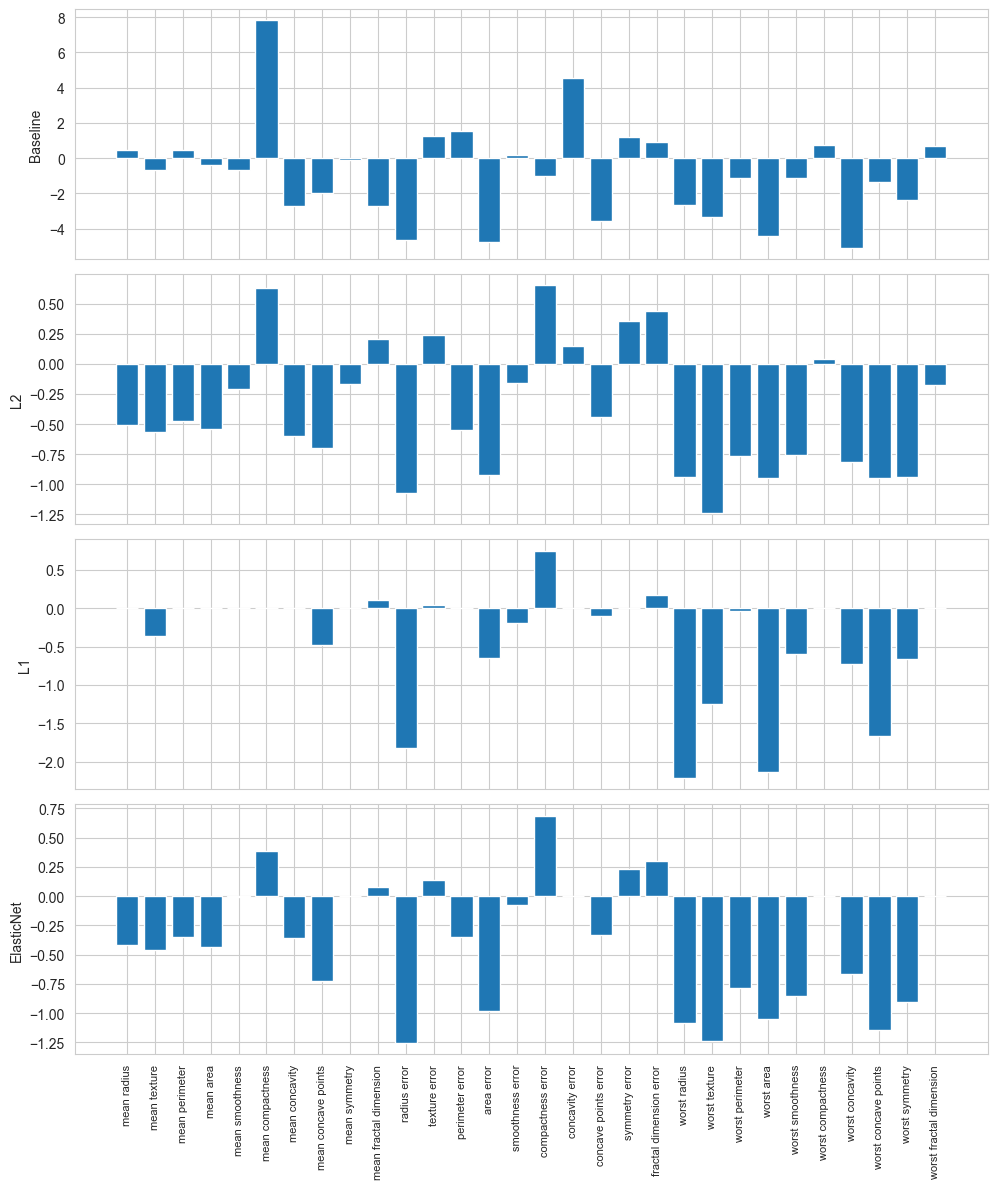

In [42]:
models = [
    ("Baseline", base.coef_),
    ("L2", l2.coef_),
    ("L1", l1.coef_),
    ("ElasticNet", en.coef_)
]
plot_coefficients(models, X.columns)

 ## Interpretation
 Baseline: Without regularization, the model is free to assign very large weights to minimize error, which often leads to overfitting (high variance).

L2 Regularization: The bars are shorter (shrunken towards zero) compared to the baseline. L2 penalizes large weights, preventing any single feature from dominating, but it rarely forces weights to be exactly zero.

L1 Regularization: there are fewer bars. L1 regularization forces the coefficients of less important features to become exactly zero. This creates a "sparse" model, effectively performing feature selection.

ElasticNet: This is a hybrid. there was some shrinkage (like L2) and some zeroed-out coefficients (like L1).

Computing L2 regularization path...


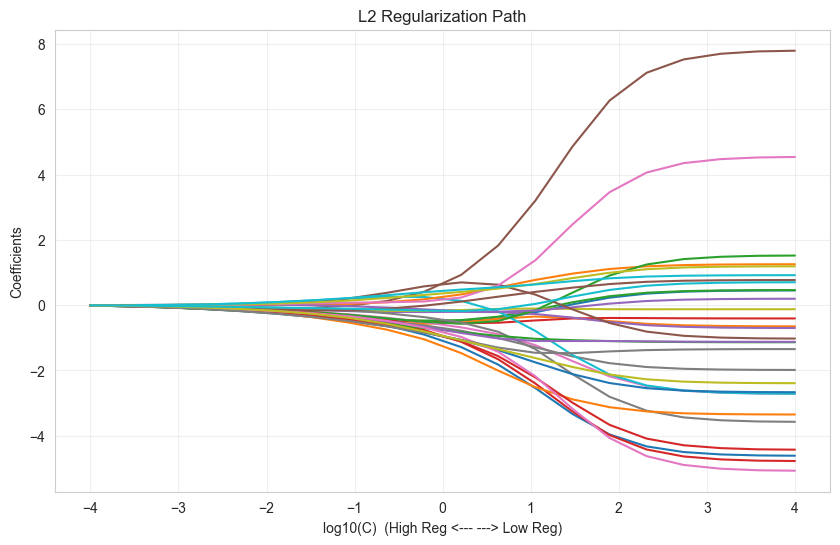

Computing L1 regularization path...


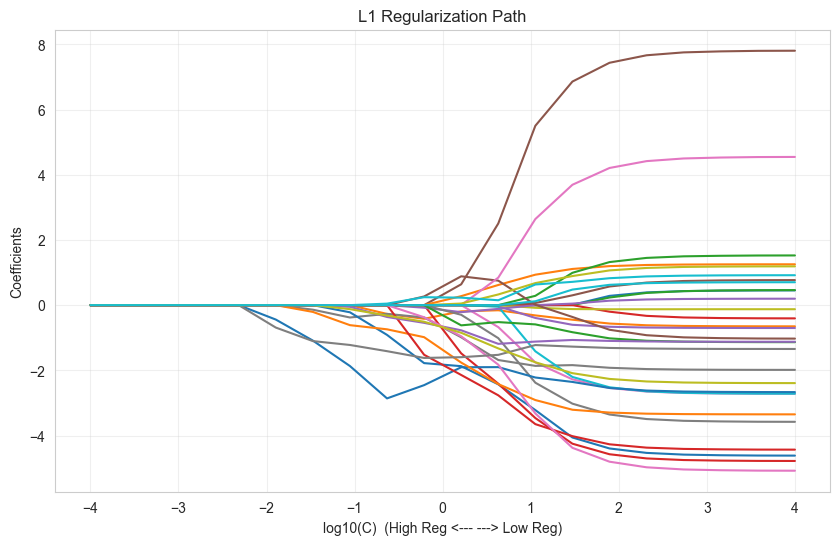

In [43]:
def plot_regularization_path(X, y, penalty='l2', solver='saga'):
    Cs = np.logspace(-4, 4, 20)
    coefs = []
    
    print(f"Computing {penalty.upper()} regularization path...")
    for C in Cs:
        clf = LogisticRegression(penalty=penalty, C=C, solver=solver, 
                                 max_iter=10000, random_state=42, warm_start=True)
        clf.fit(X, y)
        coefs.append(clf.coef_.ravel())
        
    coefs = np.array(coefs)
    
    plt.figure(figsize=(10, 6))
    plt.plot(np.log10(Cs), coefs)
    plt.xlabel('log10(C)  (High Reg <--- ---> Low Reg)')
    plt.ylabel('Coefficients')
    plt.title(f'{penalty.upper()} Regularization Path')
    plt.axis('tight')
    plt.grid(True, alpha=0.3)
    plt.show()
    
plot_regularization_path(X_train_s, y_train, penalty='l2')
plot_regularization_path(X_train_s, y_train, penalty='l1')